**1: Install Required Libraries**

In [ ]:
!pip install mediapipe opencv-python matplotlib scikit-learn tensorflow tqdm

**2: Import Libraries**

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
import tensorflow as tf
import kagglehub
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

**3: Download and Explore Dataset**

In [ ]:
# Download dataset using kagglehub
path = kagglehub.dataset_download("biratpoudelrocks/nepali-sign-language-character-dataset")
print("Path to dataset files:", path)

# List directory structure
for root, dirs, files in os.walk(path):
    print(f"Root: {root}, Dirs: {dirs}, Files: {len(files)}")

Path to dataset files: /kaggle/input/nepali-sign-language-character-dataset
Root: /kaggle/input/nepali-sign-language-character-dataset, Dirs: ['NSL'], Files: 0
Root: /kaggle/input/nepali-sign-language-character-dataset/NSL, Dirs: ['Random Background', 'Plain Background'], Files: 2
Root: /kaggle/input/nepali-sign-language-character-dataset/NSL/Random Background, Dirs: ['7', '17', '19', '22', '2', '35', '23', '10', '5', '20', '27', '32', '25', '8', '12', '0', '31', '34', '18', '28', '16', '13', '26', '15', '3', '1', '30', '14', '4', '9', '21', '6', '11', '33', '29', '24'], Files: 0
Root: /kaggle/input/nepali-sign-language-character-dataset/NSL/Random Background/7, Dirs: [], Files: 500
Root: /kaggle/input/nepali-sign-language-character-dataset/NSL/Random Background/17, Dirs: [], Files: 500
Root: /kaggle/input/nepali-sign-language-character-dataset/NSL/Random Background/19, Dirs: [], Files: 500
Root: /kaggle/input/nepali-sign-language-character-dataset/NSL/Random Background/22, Dirs: [], F

**4: Define Constants**

In [ ]:
IMG_SIZE = (64, 64)
NUM_CLASSES = 36
EPOCHS = 30
BATCH_SIZE = 32

NEPALI_CHARACTERS = [
    "ka", "kha", "ga", "gha", "nga", "cha", "chha", "ja", "jha", "nya",
    "ta", "tha", "da", "dha", "na", "ta", "tha", "da", "dha", "na",
    "pa", "pha", "ba", "bha", "ma", "ya", "ra", "la", "wa", "sha",
    "shha", "sa", "ha", "ksha", "tra", "gya"
]

**5: Get Image Paths and Labels**

In [ ]:
def get_image_paths_and_labels(data_dir, background_type):
    image_paths = []
    labels = []
    folder_path = os.path.join(data_dir, 'NSL', background_type)
    for label in range(NUM_CLASSES):
        label_folder = os.path.join(folder_path, str(label))
        if not os.path.exists(label_folder):
            continue
        for img_name in os.listdir(label_folder):
            img_path = os.path.join(label_folder, img_name)
            image_paths.append(img_path)
            labels.append(label)
    return image_paths, labels

# Get image paths
plain_paths, plain_labels = get_image_paths_and_labels(path, 'Plain Background')
random_paths, random_labels = get_image_paths_and_labels(path, 'Random Background')

image_paths = plain_paths + random_paths
labels = plain_labels + random_labels

print(f"Total image samples: {len(image_paths)}")

Total image samples: 54000


**6: Initialize MediaPipe**

In [ ]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1)
mp_drawing = mp.solutions.drawing_utils

**7: Extract Landmarks from Valid Images**

In [ ]:
def extract_hand_landmarks(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    result = hands.process(img_rgb)
    if result.multi_hand_landmarks:
        landmarks = []
        for lm in result.multi_hand_landmarks[0].landmark:
            landmarks.extend([lm.x, lm.y, lm.z])
        return landmarks
    return None

**8: Process All Images and Filter Valid Ones**

In [ ]:
X, y = [], []
for img_path, label in tqdm(zip(image_paths, labels), total=len(image_paths)):
    landmarks = extract_hand_landmarks(img_path)
    if landmarks:
        X.append(landmarks)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Valid samples with hand detected: {len(X)}")

100%|██████████| 54000/54000 [51:02<00:00, 17.63it/s]


Valid samples with hand detected: 48481


**9: Preprocess and Split Data**

In [ ]:
y_cat = tf.keras.utils.to_categorical(y, NUM_CLASSES)
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import pickle

# Save the scaler to a file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

**10: Define and Compile MLP Model**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(63,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │         2,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,788 (73.39 KB)

 Trainable params: 18,788 (73.39 KB)

 Non-trainable params: 0 (0.00 B)

**11: Train Model**

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE)

Epoch 1/30
1212/1212 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7269 - loss: 1.0975 - val_accuracy: 0.9894 - val_loss: 0.0510
Epoch 2/30
1212/1212 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9810 - loss: 0.0812 - val_accuracy: 0.9937 - val_loss: 0.0268
Epoch 3/30
1212/1212 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9870 - loss: 0.0519 - val_accuracy: 0.9946 - val_loss: 0.0204
Epoch 4/30
1212/1212 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9892 - loss: 0.0418 - val_accuracy: 0.9960 - val_loss: 0.0175
Epoch 5/30
1212/1212 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9897 - loss: 0.0371 - val_accuracy: 0.9961 - val_loss: 0.0141
Epoch 6/30
1212/1212 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9909 - loss: 0.0317 - val_accuracy: 0.9957 - val_loss: 0.0152
Epoch 7/30
1212/1212 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9913 - loss: 0.0281 - val_accuracy: 0.9961 - val_loss: 0.0159
Epoch 8/30
1212/1212 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9910 - loss: 0.0309 -

**12: Save Model**

In [ ]:
model.save("nsl_model.h5")

**13: Plot Accuracy and Loss Curves**

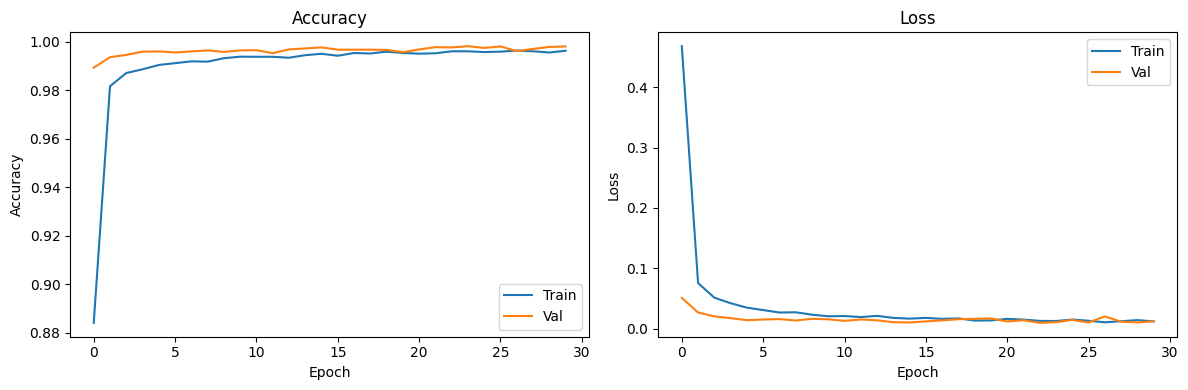

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

**14: Evaluate Model with Classification Report**

In [ ]:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=NEPALI_CHARACTERS))

304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

          ka       0.99      0.98      0.99       252
         kha       0.99      0.99      0.99       210
          ga       1.00      0.99      0.99       272
         gha       0.98      1.00      0.99       184
         nga       1.00      1.00      1.00       282
         cha       0.99      1.00      0.99       295
        chha       1.00      1.00      1.00       280
          ja       1.00      0.99      0.99       247
         jha       1.00      1.00      1.00       285
         nya       1.00      1.00      1.00       276
          ta       1.00      1.00      1.00       308
         tha       1.00      1.00      1.00       276
          da       1.00      1.00      1.00       288
         dha       1.00      1.00      1.00       247
          na       1.00      1.00      1.00       284
          ta       1.00      1.00      1.00        91
         tha    

**15: Confusion Matrix**

In [16]:
# cm = confusion_matrix(y_true, y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=NEPALI_CHARACTERS)
# disp.plot(figsize=(12, 12), xticks_rotation=90)
# plt.title("Confusion Matrix")
# plt.tight_layout()
# plt.savefig("confusion_matrix.png")
# plt.show()

TypeError: ConfusionMatrixDisplay.plot() got an unexpected keyword argument 'figsize'

**16: Visualize Multiple Hand Landmark Samples**

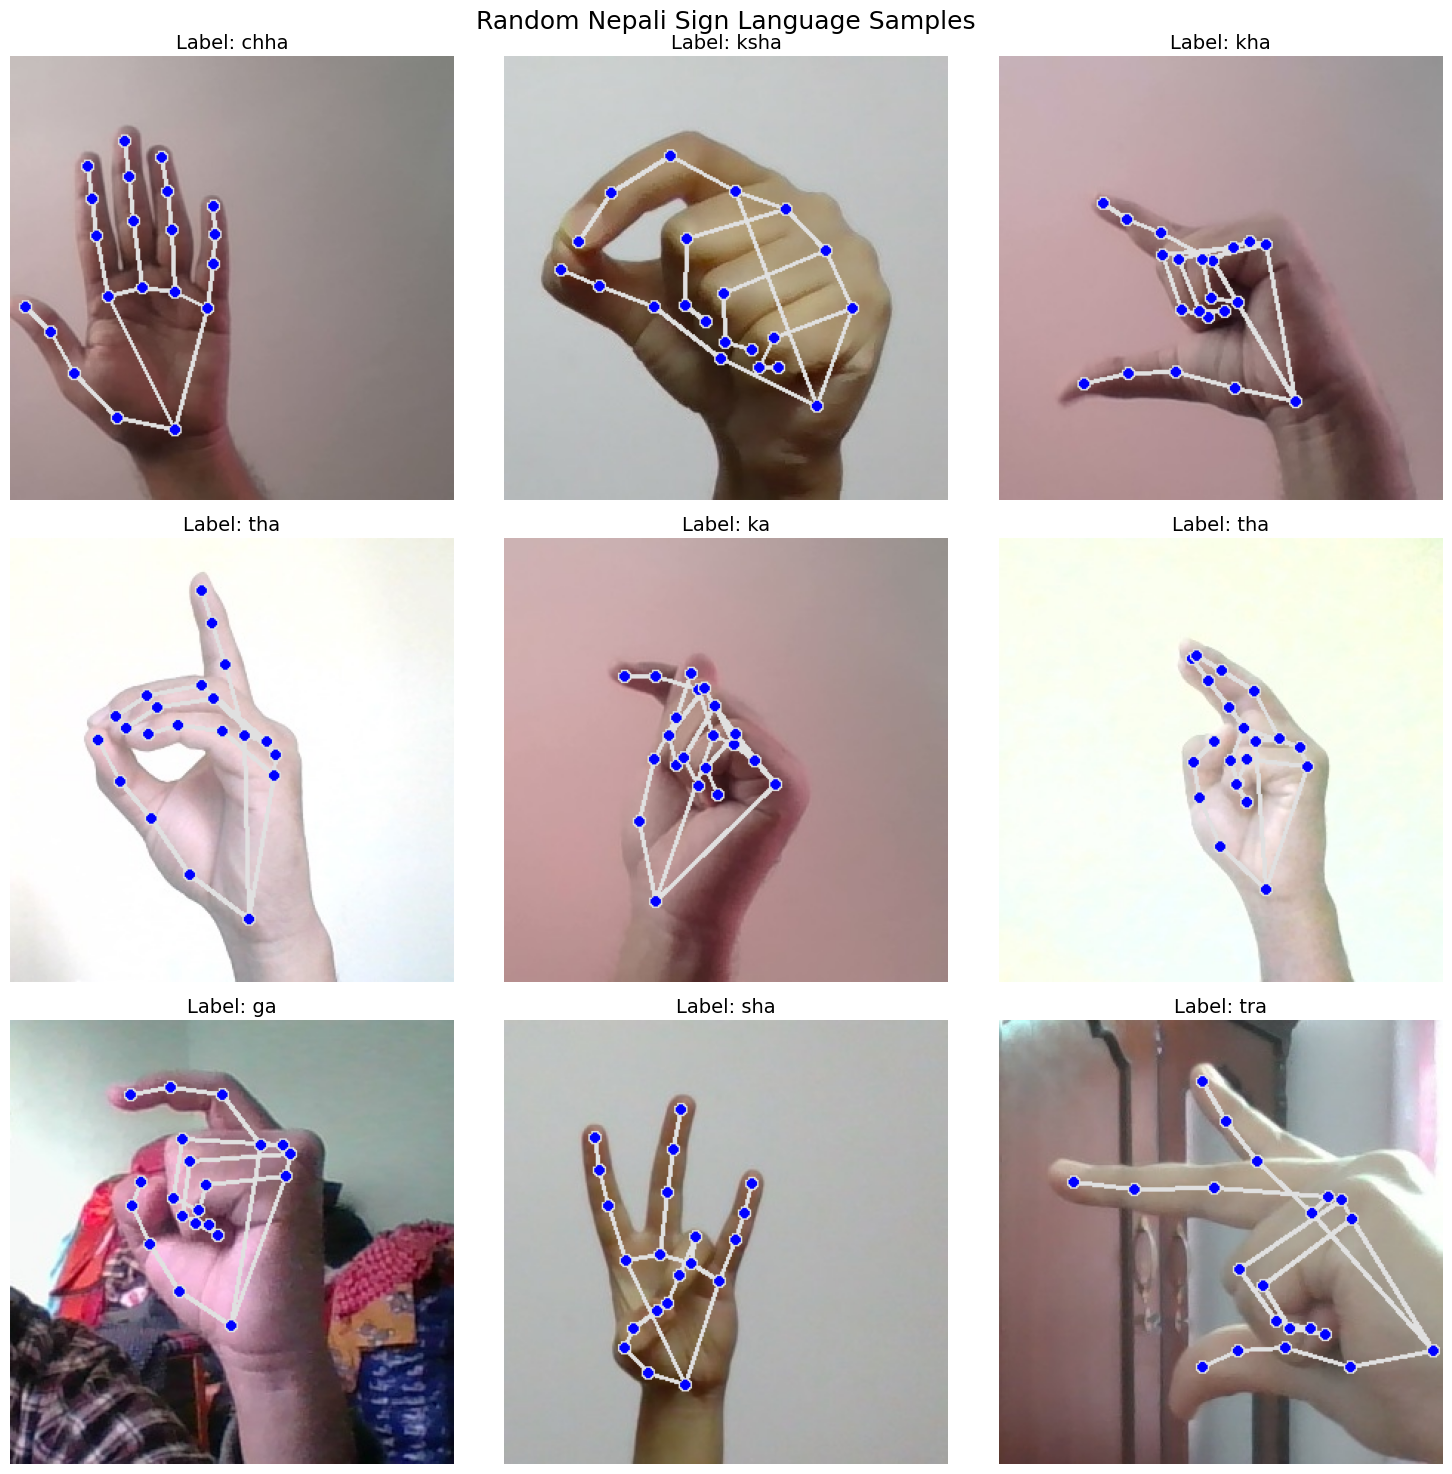

In [17]:
import random

def visualize_multiple_samples(image_paths, labels, nepali_characters, num_samples=9):
    indices = random.sample(range(len(image_paths)), num_samples)
    plt.figure(figsize=(15, 15))
    for i, idx in enumerate(indices):
        image_path = image_paths[idx]
        label = labels[idx]

        img = cv2.imread(image_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = hands.process(img_rgb)
        if result.multi_hand_landmarks:
            for hl in result.multi_hand_landmarks:
                mp_drawing.draw_landmarks(img_rgb, hl, mp_hands.HAND_CONNECTIONS)

        plt.subplot(3, 3, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"Label: {nepali_characters[label]}", fontsize=14)
        plt.axis("off")

    plt.suptitle("Random Nepali Sign Language Samples", fontsize=18)
    plt.tight_layout()
    plt.show()

# Show 9 random valid samples
visualize_multiple_samples(image_paths, labels, NEPALI_CHARACTERS, num_samples=9)